# Implementasi Fuzzy Mamdani & Sugeno (Student Performance)

Proyek ini bertujuan untuk mengimplementasikan sistem logika fuzzy dari awal (*from scratch*) menggunakan metode **Mamdani** dan **Sugeno** untuk memprediksi indeks prestasi siswa (*Student Performance Index*) berdasarkan beberapa variabel input. 

Seluruh komputasi dikembangkan secara mandiri tanpa menggunakan library fuzzy pihak ketiga, dan menggunakan operasi vektorisasi Pandas & NumPy untuk performa maksimal pada dataset berisi 10.000 data.

**Sumber Dataset:** [Kaggle - Student Performance Dataset (Multiple Linear Regression)](https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
file_path = "archive/Student_Performance.csv"
df = pd.read_csv(file_path)

# Melakukan encoding pada 'Extracurricular Activities' ('Yes' -> 1, 'No' -> 0)
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

# Print shape untuk membuktikan jumlah data 10.000 baris
print("Shape Dataset:", df.shape)

# Tampilkan 5 baris pertama
df.head(5)

Shape Dataset: (10000, 6)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


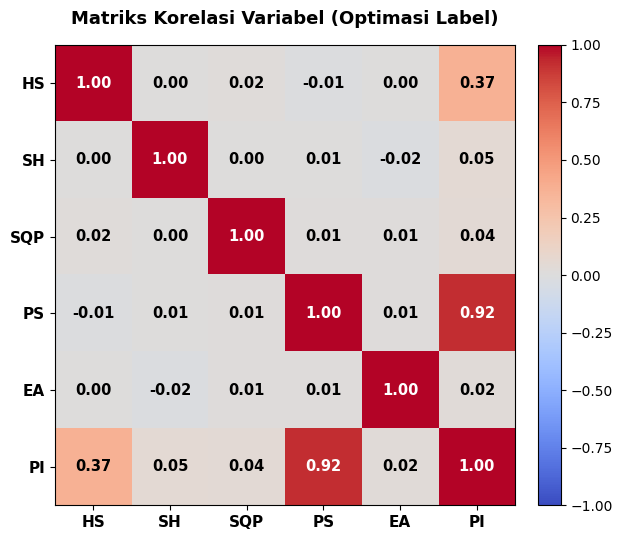

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Pilih kolom asli dan tentukan singkatan labelnya
cols_asli = ['Hours Studied', 'Sleep Hours', 'Sample Question Papers Practiced', 
             'Previous Scores', 'Extracurricular Activities', 'Performance Index']
singkatan = ['HS', 'SH', 'SQP', 'PS', 'EA', 'PI']

# Hitung matriks korelasi dari dataframe df
corr = df[cols_asli].corr()

# 2. Buat figur kanvas grafik yang fokus dan bersih
fig, ax = plt.subplots(figsize=(6.5, 5.5))
cax = ax.matshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax, fraction=0.046, pad=0.04)

# 3. Atur label sumbu X (di bawah) dan Y menggunakan singkatan
ticks = np.arange(len(singkatan))
ax.set_xticks(ticks); ax.set_yticks(ticks)
ax.xaxis.set_ticks_position('bottom')
ax.set_xticklabels(singkatan, fontsize=11, fontweight='bold')
ax.set_yticklabels(singkatan, fontsize=11, fontweight='bold')

# 4. Tulis nilai angka korelasi di dalam kotak matriks
for (i, j), val in np.ndenumerate(corr):
    warna_teks = "white" if abs(val) > 0.5 else "black"
    ax.text(j, i, f"{val:.2f}", ha='center', va='center', color=warna_teks, fontweight='bold', fontsize=10.5)

plt.title('Matriks Korelasi Variabel (Optimasi Label)', pad=15, fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

**Keterangan Singkatan Variabel:**
* **HS** : *Hours Studied* (Jam Belajar)
* **SH** : *Sleep Hours* (Jam Tidur)
* **SQP** : *Sample Question Papers Practiced* (Latihan Soal)
* **PS** : *Previous Scores* (Nilai Sebelumnya)
* **EA** : *Extracurricular Activities* (Kegiatan Ekstrakurikuler)
* **PI** : *Performance Index* (Indeks Prestasi Siswa - Variabel Target)

## Variabel Input, Output, dan Variabel Linguistik

Sistem pakar ini memiliki **5 Variabel Input** dan **1 Variabel Output**:

### 1. Variabel Input:
*   **Hours Studied**: Jumlah jam belajar siswa per hari.
    *   *Rentang*: 1 - 9
    *   *Variabel Linguistik*: Sedikit, Sedang, Banyak
*   **Sleep Hours**: Jumlah jam tidur siswa per hari.
    *   *Rentang*: 4 - 9
    *   *Variabel Linguistik*: Kurang, Cukup, Berlebih
*   **Sample Question Papers Practiced**: Jumlah latihan soal yang dikerjakan siswa.
    *   *Rentang*: 0 - 9
    *   *Variabel Linguistik*: Jarang, Lumayan, Sering
*   **Previous Scores**: Nilai ujian siswa sebelumnya.
    *   *Rentang*: 40 - 99 (dimodelkan dari 0 - 100)
    *   *Variabel Linguistik*: Rendah, Menengah, Tinggi
*   **Extracurricular Activities**: Keaktifan dalam kegiatan ekstrakurikuler.
    *   *Rentang*: Biner (0 = No, 1 = Yes)

### 2. Variabel Output:
*   **Performance Index**: Indeks prestasi siswa.
    *   *Rentang*: 10 - 100
    *   *Variabel Linguistik*: Buruk, Cukup, Sangat Baik

In [3]:
# Batas-batas fungsi keanggotaan (Membership Function)
fuzzy_bounds = {
    'Hours Studied': {
        'Sedikit': (1, 1, 2, 4),
        'Sedang': (3, 5, 7),
        'Banyak': (6, 8, 9, 9)
    },
    'Sleep Hours': {
        'Kurang': (4, 4, 6),
        'Cukup': (5, 6, 7, 8),
        'Berlebih': (7, 8, 9, 9)
    },
    'Sample Question Papers Practiced': {
        'Jarang': (0, 0, 1, 3),
        'Lumayan': (2, 4, 6),
        'Sering': (5, 7, 9, 9)
    },
    'Previous Scores': {
        'Rendah': (0, 0, 45, 55),
        'Menengah': (50, 60, 65, 75),
        'Tinggi': (70, 85, 100, 100)
    },
    'Performance Index': {
        'Buruk': (10, 10, 45),
        'Cukup': (35, 55, 75),
        'Sangat Baik': (65, 100, 100)
    }
}

def hitung_keanggotaan(x, batas):
    # Penanganan kurva Segitiga
    if len(batas) == 3:
        a, b, c = batas
        # Perbaikan: Gunakan < dan > absolut, bukan <= atau >=
        if x < a or x > c: 
            return 0.0
        elif x == b: 
            return 1.0
        elif a <= x < b: 
            return float(x - a) / (b - a)
        elif b < x <= c: 
            return float(c - x) / (c - b)
            
    # Penanganan kurva Trapesium
    elif len(batas) == 4:
        a, b, c, d = batas
        # Perbaikan: Gunakan < dan > absolut
        if x < a or x > d: 
            return 0.0
        elif b <= x <= c: 
            return 1.0
        elif a <= x < b: 
            return float(x - a) / (b - a)
        elif c < x <= d: 
            return float(d - x) / (d - c)
            
    return 0.0


# Visualisasi Seluruh Kurva Fungsi Keanggotaan

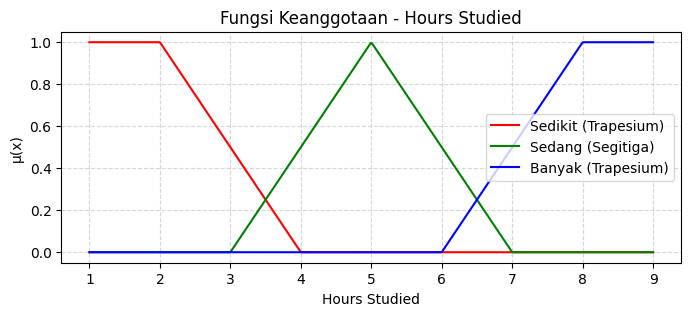

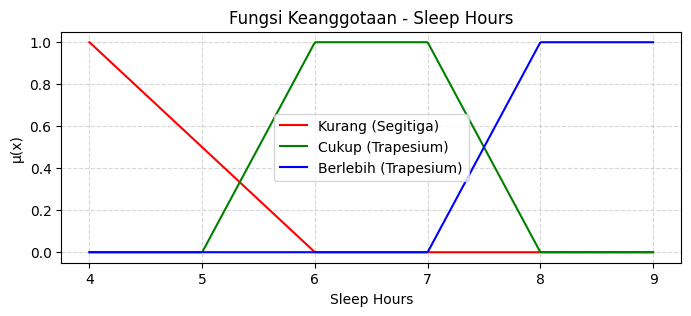

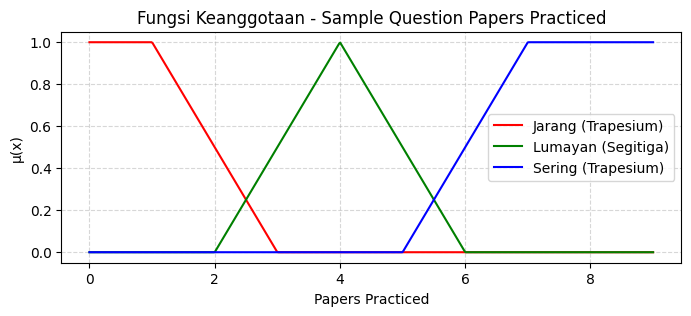

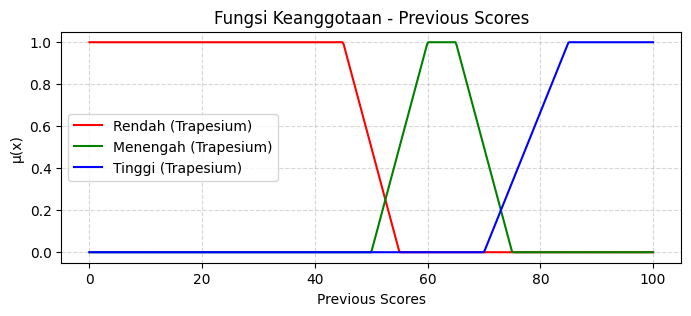

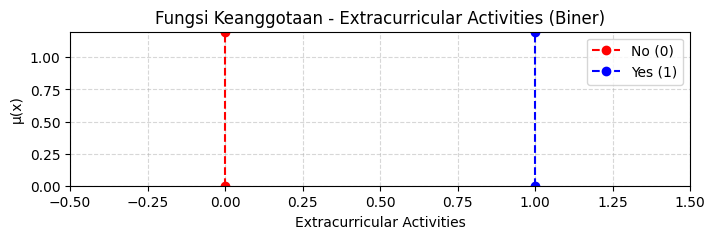

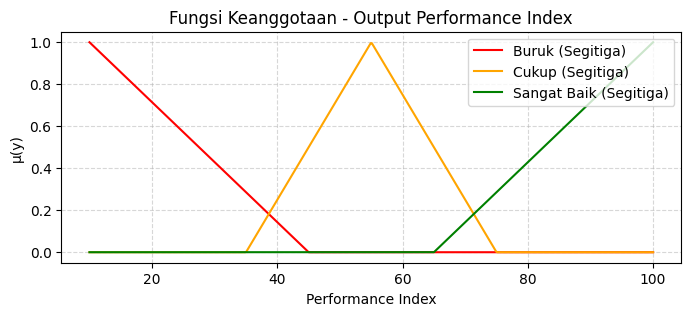

In [4]:
# WAJIB menggambar 6 grafik terpisah secara berurutan

# 1. Hours Studied
x = np.linspace(1, 9, 500)
y_sedikit = [hitung_keanggotaan(val, fuzzy_bounds['Hours Studied']['Sedikit']) for val in x]
y_sedang = [hitung_keanggotaan(val, fuzzy_bounds['Hours Studied']['Sedang']) for val in x]
y_banyak = [hitung_keanggotaan(val, fuzzy_bounds['Hours Studied']['Banyak']) for val in x]

plt.figure(figsize=(8, 3))
plt.plot(x, y_sedikit, label='Sedikit (Trapesium)', color='red')
plt.plot(x, y_sedang, label='Sedang (Segitiga)', color='green')
plt.plot(x, y_banyak, label='Banyak (Trapesium)', color='blue')
plt.title('Fungsi Keanggotaan - Hours Studied')
plt.xlabel('Hours Studied')
plt.ylabel('μ(x)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 2. Sleep Hours
x = np.linspace(4, 9, 500)
y_kurang = [hitung_keanggotaan(val, fuzzy_bounds['Sleep Hours']['Kurang']) for val in x]
y_cukup = [hitung_keanggotaan(val, fuzzy_bounds['Sleep Hours']['Cukup']) for val in x]
y_berlebih = [hitung_keanggotaan(val, fuzzy_bounds['Sleep Hours']['Berlebih']) for val in x]

plt.figure(figsize=(8, 3))
plt.plot(x, y_kurang, label='Kurang (Segitiga)', color='red')
plt.plot(x, y_cukup, label='Cukup (Trapesium)', color='green')
plt.plot(x, y_berlebih, label='Berlebih (Trapesium)', color='blue')
plt.title('Fungsi Keanggotaan - Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('μ(x)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 3. Sample Question Papers Practiced
x = np.linspace(0, 9, 500)
y_jarang = [hitung_keanggotaan(val, fuzzy_bounds['Sample Question Papers Practiced']['Jarang']) for val in x]
y_lumayan = [hitung_keanggotaan(val, fuzzy_bounds['Sample Question Papers Practiced']['Lumayan']) for val in x]
y_sering = [hitung_keanggotaan(val, fuzzy_bounds['Sample Question Papers Practiced']['Sering']) for val in x]

plt.figure(figsize=(8, 3))
plt.plot(x, y_jarang, label='Jarang (Trapesium)', color='red')
plt.plot(x, y_lumayan, label='Lumayan (Segitiga)', color='green')
plt.plot(x, y_sering, label='Sering (Trapesium)', color='blue')
plt.title('Fungsi Keanggotaan - Sample Question Papers Practiced')
plt.xlabel('Papers Practiced')
plt.ylabel('μ(x)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 4. Previous Scores
x = np.linspace(0, 100, 500)
y_rendah = [hitung_keanggotaan(val, fuzzy_bounds['Previous Scores']['Rendah']) for val in x]
y_menengah = [hitung_keanggotaan(val, fuzzy_bounds['Previous Scores']['Menengah']) for val in x]
y_tinggi = [hitung_keanggotaan(val, fuzzy_bounds['Previous Scores']['Tinggi']) for val in x]

plt.figure(figsize=(8, 3))
plt.plot(x, y_rendah, label='Rendah (Trapesium)', color='red')
plt.plot(x, y_menengah, label='Menengah (Trapesium)', color='green')
plt.plot(x, y_tinggi, label='Tinggi (Trapesium)', color='blue')
plt.title('Fungsi Keanggotaan - Previous Scores')
plt.xlabel('Previous Scores')
plt.ylabel('μ(x)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 5. Extracurricular (Opsional karena biner)
plt.figure(figsize=(8, 2))
plt.axvline(0, 0, 1, label='No (0)', color='red', linestyle='--', marker='o')
plt.axvline(1, 0, 1, label='Yes (1)', color='blue', linestyle='--', marker='o')
plt.xlim(-0.5, 1.5)
plt.ylim(0, 1.2)
plt.title('Fungsi Keanggotaan - Extracurricular Activities (Biner)')
plt.xlabel('Extracurricular Activities')
plt.ylabel('μ(x)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 6. Output Performance Index
x = np.linspace(10, 100, 500)
y_buruk = [hitung_keanggotaan(val, fuzzy_bounds['Performance Index']['Buruk']) for val in x]
y_cukup = [hitung_keanggotaan(val, fuzzy_bounds['Performance Index']['Cukup']) for val in x]
y_sangat_baik = [hitung_keanggotaan(val, fuzzy_bounds['Performance Index']['Sangat Baik']) for val in x]

plt.figure(figsize=(8, 3))
plt.plot(x, y_buruk, label='Buruk (Segitiga)', color='red')
plt.plot(x, y_cukup, label='Cukup (Segitiga)', color='orange')
plt.plot(x, y_sangat_baik, label='Sangat Baik (Segitiga)', color='green')
plt.title('Fungsi Keanggotaan - Output Performance Index')
plt.xlabel('Performance Index')
plt.ylabel('μ(y)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Demonstrasi Manual Fuzzifikasi (Indeks 0)

Pembuktian perhitungan fuzzifikasi untuk satu sampel data siswa pertama (indeks 0). Nilai tegas (*crisp*) asli akan diubah menjadi nilai keanggotaan fuzzy.

In [5]:
# Mengambil sampel data baris pertama
sampel_data = df.iloc[0]

# Print nilai tegas asli secara terurut
print("--- DATA ASLI (CRISP) ---")
print(f"Hours Studied: {sampel_data['Hours Studied']}")
print(f"Sleep Hours: {sampel_data['Sleep Hours']}")
print(f"Sample Question Papers Practiced: {sampel_data['Sample Question Papers Practiced']}")
print(f"Previous Scores: {sampel_data['Previous Scores']}")
print(f"Extracurricular Activities: {sampel_data['Extracurricular Activities']}")
print()

# Print bagian hasil fuzzifikasi
print("--- HASIL FUZZIFIKASI ---")

# Fuzzifikasi Hours Studied
f_hours_sedikit = hitung_keanggotaan(sampel_data['Hours Studied'], fuzzy_bounds['Hours Studied']['Sedikit'])
f_hours_sedang = hitung_keanggotaan(sampel_data['Hours Studied'], fuzzy_bounds['Hours Studied']['Sedang'])
f_hours_banyak = hitung_keanggotaan(sampel_data['Hours Studied'], fuzzy_bounds['Hours Studied']['Banyak'])

# Fuzzifikasi Sleep Hours
f_sleep_kurang = hitung_keanggotaan(sampel_data['Sleep Hours'], fuzzy_bounds['Sleep Hours']['Kurang'])
f_sleep_cukup = hitung_keanggotaan(sampel_data['Sleep Hours'], fuzzy_bounds['Sleep Hours']['Cukup'])
f_sleep_berlebih = hitung_keanggotaan(sampel_data['Sleep Hours'], fuzzy_bounds['Sleep Hours']['Berlebih'])

# Fuzzifikasi Sample Question
f_practice_jarang = hitung_keanggotaan(sampel_data['Sample Question Papers Practiced'], fuzzy_bounds['Sample Question Papers Practiced']['Jarang'])
f_practice_lumayan = hitung_keanggotaan(sampel_data['Sample Question Papers Practiced'], fuzzy_bounds['Sample Question Papers Practiced']['Lumayan'])
f_practice_sering = hitung_keanggotaan(sampel_data['Sample Question Papers Practiced'], fuzzy_bounds['Sample Question Papers Practiced']['Sering'])

# Fuzzifikasi Previous Scores
f_score_rendah = hitung_keanggotaan(sampel_data['Previous Scores'], fuzzy_bounds['Previous Scores']['Rendah'])
f_score_menengah = hitung_keanggotaan(sampel_data['Previous Scores'], fuzzy_bounds['Previous Scores']['Menengah'])
f_score_tinggi = hitung_keanggotaan(sampel_data['Previous Scores'], fuzzy_bounds['Previous Scores']['Tinggi'])

# Mencetak output derajat keanggotaan fuzzy
print(f"Hours Studied -> Sedikit: {f_hours_sedikit}, Sedang: {f_hours_sedang}, Banyak: {f_hours_banyak}")
print(f"Sleep Hours -> Kurang: {f_sleep_kurang}, Cukup: {f_sleep_cukup}, Berlebih: {f_sleep_berlebih}")
print(f"Sample Question -> Jarang: {f_practice_jarang}, Lumayan: {f_practice_lumayan}, Sering: {f_practice_sering}")
print(f"Previous Scores -> Rendah: {f_score_rendah}, Menengah: {f_score_menengah}, Tinggi: {f_score_tinggi}")

--- DATA ASLI (CRISP) ---
Hours Studied: 7.0
Sleep Hours: 9.0
Sample Question Papers Practiced: 1.0
Previous Scores: 99.0
Extracurricular Activities: 1.0

--- HASIL FUZZIFIKASI ---
Hours Studied -> Sedikit: 0.0, Sedang: 0.0, Banyak: 0.5
Sleep Hours -> Kurang: 0.0, Cukup: 0.0, Berlebih: 1.0
Sample Question -> Jarang: 1.0, Lumayan: 0.0, Sering: 0.0
Previous Scores -> Rendah: 0.0, Menengah: 0.0, Tinggi: 1.0


### Demonstrasi Manual Inferensi & Defuzzifikasi (Indeks 0)

Pembuktian proses penalaran aturan (*rule evaluation*) serta pencarian nilai tegas akhir secara matematis murni untuk siswa pertama (indeks 0).


In [6]:
# A. Evaluasi 15 Aturan Manual secara Skalar
r1 = min(f_hours_banyak, f_sleep_cukup, f_practice_sering, f_score_tinggi)
r2 = min(f_hours_banyak, f_practice_sering, f_score_menengah)
r3 = min(f_hours_sedang, f_practice_lumayan, f_score_tinggi)
r4 = min(f_hours_banyak, f_sleep_cukup, sampel_data['Extracurricular Activities'], f_practice_lumayan)
r5 = min(f_practice_sering, f_score_tinggi, f_sleep_berlebih)

r6 = min(f_hours_sedang, f_sleep_cukup, f_score_menengah)
r7 = min(f_score_tinggi, f_hours_sedikit, f_practice_jarang)
r8 = min(f_hours_banyak, f_sleep_kurang, f_score_menengah, sampel_data['Extracurricular Activities'])
r9 = min(f_hours_banyak, f_score_rendah)
r10 = min(f_sleep_cukup, f_practice_lumayan, f_score_menengah)

r11 = min(f_hours_sedikit, f_sleep_kurang, f_score_rendah)
r12 = min(f_sleep_berlebih, f_hours_sedikit, f_practice_jarang)
r13 = min(f_practice_jarang, f_score_rendah, f_hours_sedang)
r14 = min(sampel_data['Extracurricular Activities'], f_hours_sedikit, f_score_menengah)
r15 = min(f_hours_sedang, f_sleep_kurang, f_score_rendah)

# B. Cetak Aturan Aktif
rules = {
    "Rule 1": r1, "Rule 2": r2, "Rule 3": r3, "Rule 4": r4, "Rule 5": r5,
    "Rule 6": r6, "Rule 7": r7, "Rule 8": r8, "Rule 9": r9, "Rule 10": r10,
    "Rule 11": r11, "Rule 12": r12, "Rule 13": r13, "Rule 14": r14, "Rule 15": r15
}
print("--- ATURAN AKTIF ---")
any_active = False
for name, val in rules.items():
    if val > 0:
        print(f"{name} Aktif, Alpha = {val}")
        any_active = True
if not any_active:
    print("Tidak ada aturan yang aktif (semua Alpha = 0.0)")
print()

# C. Agregasi Konsekuen
alpha_sangat_baik = max(r1, r2, r3, r4, r5)
alpha_cukup = max(r6, r7, r8, r9, r10)
alpha_buruk = max(r11, r12, r13, r14, r15)

print("--- AGREGASI KONSEKUEN ---")
print(f"Alpha Buruk       : {alpha_buruk}")
print(f"Alpha Cukup       : {alpha_cukup}")
print(f"Alpha Sangat Baik : {alpha_sangat_baik}")
print()

# D. Defuzzifikasi Sugeno Manual
k_buruk = 30
k_cukup = 65
k_sangat_baik = 90

print("--- DEFUZZIFIKASI SUGENO (WEIGHTED AVERAGE) ---")
print("Rumus Weighted Average:")
print("z = (Alpha_Buruk * k_Buruk + Alpha_Cukup * k_Cukup + Alpha_Sangat_Baik * k_Sangat_Baik) / (Alpha_Buruk + Alpha_Cukup + Alpha_Sangat_Baik)")
print()

pembilang_sugeno = (alpha_buruk * k_buruk) + (alpha_cukup * k_cukup) + (alpha_sangat_baik * k_sangat_baik)
penyebut_sugeno = alpha_buruk + alpha_cukup + alpha_sangat_baik

print("Substitusi angka:")
print(f"z = ({alpha_buruk} * {k_buruk} + {alpha_cukup} * {k_cukup} + {alpha_sangat_baik} * {k_sangat_baik}) / ({alpha_buruk} + {alpha_cukup} + {alpha_sangat_baik})")

if penyebut_sugeno == 0:
    prediksi_sugeno = 65.0
else:
    prediksi_sugeno = pembilang_sugeno / penyebut_sugeno

print(f"z = {pembilang_sugeno} / {penyebut_sugeno}")
print(f"Hasil Prediksi Sugeno Manual: {prediksi_sugeno}")
print()

# E. Defuzzifikasi Mamdani Manual
import numpy as np
z_values = np.arange(10, 101)
bounds_output = fuzzy_bounds['Performance Index']
mu_buruk = np.array([hitung_keanggotaan(z, bounds_output['Buruk']) for z in z_values])
mu_cukup = np.array([hitung_keanggotaan(z, bounds_output['Cukup']) for z in z_values])
mu_sangat_baik = np.array([hitung_keanggotaan(z, bounds_output['Sangat Baik']) for z in z_values])

area_gabungan = []
for idx, z in enumerate(z_values):
    cut_buruk = min(alpha_buruk, mu_buruk[idx])
    cut_cukup = min(alpha_cukup, mu_cukup[idx])
    cut_sangat_baik = min(alpha_sangat_baik, mu_sangat_baik[idx])
    val_gabung = max(cut_buruk, cut_cukup, cut_sangat_baik)
    area_gabungan.append(val_gabung)

area_gabungan = np.array(area_gabungan)
sum_area = np.sum(area_gabungan)
sum_z_area = np.sum(z_values * area_gabungan)

print("--- DEFUZZIFIKASI MAMDANI (CENTROID Diskret) ---")
print(f"Total perkiraan luasan area (sum_area)                  = {sum_area}")
print(f"Total perkalian titik berat (sum_z_area)                = {sum_z_area}")

if sum_area == 0:
    prediksi_mamdani = 55.0
else:
    prediksi_mamdani = sum_z_area / sum_area

print(f"z = {sum_z_area} / {sum_area}")
print(f"Hasil Prediksi Mamdani Manual: {prediksi_mamdani}")


--- ATURAN AKTIF ---
Tidak ada aturan yang aktif (semua Alpha = 0.0)

--- AGREGASI KONSEKUEN ---
Alpha Buruk       : 0.0
Alpha Cukup       : 0.0
Alpha Sangat Baik : 0.0

--- DEFUZZIFIKASI SUGENO (WEIGHTED AVERAGE) ---
Rumus Weighted Average:
z = (Alpha_Buruk * k_Buruk + Alpha_Cukup * k_Cukup + Alpha_Sangat_Baik * k_Sangat_Baik) / (Alpha_Buruk + Alpha_Cukup + Alpha_Sangat_Baik)

Substitusi angka:
z = (0.0 * 30 + 0.0 * 65 + 0.0 * 90) / (0.0 + 0.0 + 0.0)
z = 0.0 / 0.0
Hasil Prediksi Sugeno Manual: 65.0

--- DEFUZZIFIKASI MAMDANI (CENTROID Diskret) ---
Total perkiraan luasan area (sum_area)                  = 0.0
Total perkalian titik berat (sum_z_area)                = 0.0
z = 0.0 / 0.0
Hasil Prediksi Mamdani Manual: 55.0


## Tabel Rule Base (15 Aturan)

Berikut adalah tabel 15 aturan logika fuzzy IF-THEN yang telah disepakati:

| No | Hours Studied | Sleep Hours | Papers Practiced | Previous Scores | Extracurricular | Output (Performance Index) |
|---|---|---|---|---|---|---|
| 1 | Banyak | Cukup | Sering | Tinggi | - | Sangat Baik |
| 2 | Banyak | - | Sering | Menengah | - | Sangat Baik |
| 3 | Sedang | - | Lumayan | Tinggi | - | Sangat Baik |
| 4 | Banyak | Cukup | Lumayan | - | Yes (1) | Sangat Baik |
| 5 | - | Berlebih | Sering | Tinggi | - | Sangat Baik |
| 6 | Sedang | Cukup | - | Menengah | - | Cukup |
| 7 | Sedikit | - | Jarang | Tinggi | - | Cukup |
| 8 | Banyak | Kurang | - | Menengah | Yes (1) | Cukup |
| 9 | Banyak | - | - | Rendah | - | Cukup |
| 10| - | Cukup | Lumayan | Menengah | - | Cukup |
| 11| Sedikit | Kurang | - | Rendah | - | Buruk |
| 12| Sedikit | Berlebih| Jarang | - | - | Buruk |
| 13| Sedang | - | Jarang | Rendah | - | Buruk |
| 14| Sedikit | - | - | Menengah | Yes (1) | Buruk |
| 15| Sedang | Kurang | - | Rendah | - | Buruk |

In [7]:
# Eksekusi Fuzzifikasi massal ke seluruh 10.000 baris
for kolom, kategori_dict in fuzzy_bounds.items():
    if kolom == 'Performance Index':
        continue
    for nama_kategori, batas in kategori_dict.items():
        df[f"{kolom}_{nama_kategori}"] = df[kolom].apply(lambda x: hitung_keanggotaan(x, batas))

# Inferensi Rule_1 s.d. Rule_15 menggunakan np.minimum.reduce
# Aturan Sangat Baik
df['Rule_1'] = np.minimum.reduce([df['Hours Studied_Banyak'], df['Sleep Hours_Cukup'], df['Sample Question Papers Practiced_Sering'], df['Previous Scores_Tinggi']])
df['Rule_2'] = np.minimum.reduce([df['Hours Studied_Banyak'], df['Sample Question Papers Practiced_Sering'], df['Previous Scores_Menengah']])
df['Rule_3'] = np.minimum.reduce([df['Hours Studied_Sedang'], df['Sample Question Papers Practiced_Lumayan'], df['Previous Scores_Tinggi']])
df['Rule_4'] = np.minimum.reduce([df['Hours Studied_Banyak'], df['Sleep Hours_Cukup'], df['Extracurricular Activities'], df['Sample Question Papers Practiced_Lumayan']])
df['Rule_5'] = np.minimum.reduce([df['Sample Question Papers Practiced_Sering'], df['Previous Scores_Tinggi'], df['Sleep Hours_Berlebih']])

# Aturan Cukup
df['Rule_6'] = np.minimum.reduce([df['Hours Studied_Sedang'], df['Sleep Hours_Cukup'], df['Previous Scores_Menengah']])
df['Rule_7'] = np.minimum.reduce([df['Previous Scores_Tinggi'], df['Hours Studied_Sedikit'], df['Sample Question Papers Practiced_Jarang']])
df['Rule_8'] = np.minimum.reduce([df['Hours Studied_Banyak'], df['Sleep Hours_Kurang'], df['Previous Scores_Menengah'], df['Extracurricular Activities']])
df['Rule_9'] = np.minimum(df['Hours Studied_Banyak'], df['Previous Scores_Rendah'])
df['Rule_10'] = np.minimum.reduce([df['Sleep Hours_Cukup'], df['Sample Question Papers Practiced_Lumayan'], df['Previous Scores_Menengah']])

# Aturan Buruk
df['Rule_11'] = np.minimum.reduce([df['Hours Studied_Sedikit'], df['Sleep Hours_Kurang'], df['Previous Scores_Rendah']])
df['Rule_12'] = np.minimum.reduce([df['Sleep Hours_Berlebih'], df['Hours Studied_Sedikit'], df['Sample Question Papers Practiced_Jarang']])
df['Rule_13'] = np.minimum.reduce([df['Sample Question Papers Practiced_Jarang'], df['Previous Scores_Rendah'], df['Hours Studied_Sedang']])
df['Rule_14'] = np.minimum.reduce([df['Extracurricular Activities'], df['Hours Studied_Sedikit'], df['Previous Scores_Menengah']])
df['Rule_15'] = np.minimum.reduce([df['Hours Studied_Sedang'], df['Sleep Hours_Kurang'], df['Previous Scores_Rendah']])

# Agregasi Alpha menggunakan np.maximum.reduce
df['Alpha_Sangat_Baik'] = np.maximum.reduce([df['Rule_1'], df['Rule_2'], df['Rule_3'], df['Rule_4'], df['Rule_5']])
df['Alpha_Cukup'] = np.maximum.reduce([df['Rule_6'], df['Rule_7'], df['Rule_8'], df['Rule_9'], df['Rule_10']])
df['Alpha_Buruk'] = np.maximum.reduce([df['Rule_11'], df['Rule_12'], df['Rule_13'], df['Rule_14'], df['Rule_15']])

print("Inferensi dan Agregasi Berhasil Diselesaikan untuk 10.000 baris data.")
df[['Alpha_Buruk', 'Alpha_Cukup', 'Alpha_Sangat_Baik']].head(5)

Inferensi dan Agregasi Berhasil Diselesaikan untuk 10.000 baris data.


,Alpha_Buruk,Alpha_Cukup,Alpha_Sangat_Baik
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.4,0.0
3,0.3,0.0,0.0
4,0.0,0.0,0.0


# Metode Defuzzifikasi

Untuk mengubah hasil inferensi fuzzy berupa derajat keanggotaan output (Alpha) menjadi nilai tegas, digunakan dua metode defuzzifikasi:

1.  **Sugeno (Weighted Average)**:
    Menggunakan model Orde-0 di mana setiap kategori output direpresentasikan oleh konstanta (*singleton*):
    *   Buruk = 10
    *   Cukup = 55
    *   Sangat Baik = 100
    *   *Rumus*: 
        $$z = \frac{\alpha_{\text{Buruk}} \cdot 10 + \alpha_{\text{Cukup}} \cdot 55 + \alpha_{\text{Sangat Baik}} \cdot 100}{\alpha_{\text{Buruk}} + \alpha_{\text{Cukup}} + \alpha_{\text{Sangat Baik}}}$$

2.  **Mamdani (Centroid)**:
    Menggunakan diskritisasi manual dari area kurva output. Area dihitung pada sumbu $z$ dari 10 hingga 100 dengan step 1. Derajat keanggotaan pada area gabungan diperoleh dari $\max$ hasil pemotongan kurva dasar masing-masing output.
    *   *Rumus*:
        $$z = \frac{\sum z_i \cdot \mu_{\text{gabungan}}(z_i)}{\sum \mu_{\text{gabungan}}(z_i)}$$

In [8]:
# 1. Defuzzifikasi Sugeno
total_alpha = df['Alpha_Buruk'] + df['Alpha_Cukup'] + df['Alpha_Sangat_Baik']
pembilang_sugeno = (df['Alpha_Buruk'] * 10) + (df['Alpha_Cukup'] * 55) + (df['Alpha_Sangat_Baik'] * 100)
df['Prediksi_Sugeno'] = np.where(
    total_alpha == 0, 
    55.0, 
    pembilang_sugeno / np.where(total_alpha == 0, 1.0, total_alpha)
)

# 2. Defuzzifikasi Mamdani
# Diskritisasi sumbu z dari 10 sampai 100
z_values = np.arange(10, 101)
bounds_output = fuzzy_bounds['Performance Index']
mu_buruk = np.array([hitung_keanggotaan(z, bounds_output['Buruk']) for z in z_values])
mu_cukup = np.array([hitung_keanggotaan(z, bounds_output['Cukup']) for z in z_values])
mu_sangat_baik = np.array([hitung_keanggotaan(z, bounds_output['Sangat Baik']) for z in z_values])

def defuzzifikasi_mamdani(alpha_buruk, alpha_cukup, alpha_sb):
    if (alpha_buruk + alpha_cukup + alpha_sb) == 0:
        return 55.0
        
    cut_buruk = np.minimum(alpha_buruk, mu_buruk)
    cut_cukup = np.minimum(alpha_cukup, mu_cukup)
    cut_sangat_baik = np.minimum(alpha_sb, mu_sangat_baik)
    
    area_gabungan = np.maximum(np.maximum(cut_buruk, cut_cukup), cut_sangat_baik)
    sum_area = np.sum(area_gabungan)
    
    if sum_area == 0:
        return 55.0
        
    return np.sum(z_values * area_gabungan) / sum_area

# Terapkan Mamdani ke seluruh dataset (10.000 baris)
df['Prediksi_Mamdani'] = df.apply(
    lambda r: defuzzifikasi_mamdani(r['Alpha_Buruk'], r['Alpha_Cukup'], r['Alpha_Sangat_Baik']),
    axis=1
)

# Tampilkan hasil perbandingan 5 baris pertama berdampingan dengan target aktual
print("=== PERBANDINGAN PREDIKSI MAMDANI & SUGENO ===")
df[['Performance Index', 'Prediksi_Sugeno', 'Prediksi_Mamdani']].head(5)

=== PERBANDINGAN PREDIKSI MAMDANI & SUGENO ===


,Performance Index,Prediksi_Sugeno,Prediksi_Mamdani
0,91.0,55.0,55.000000
1,65.0,55.0,55.000000
2,45.0,55.0,55.000000
3,36.0,10.0,24.771654
4,66.0,55.0,55.000000


# Evaluasi Performa Model (MAE & MSE)

Dilarang menggunakan `sklearn.metrics`. Evaluasi dihitung menggunakan operasi `numpy` murni secara langsung.

In [9]:
# Evaluasi Sugeno
mae_sugeno = np.mean(np.abs(df['Prediksi_Sugeno'] - df['Performance Index']))
mse_sugeno = np.mean((df['Prediksi_Sugeno'] - df['Performance Index'])**2)

# Evaluasi Mamdani
mae_mamdani = np.mean(np.abs(df['Prediksi_Mamdani'] - df['Performance Index']))
mse_mamdani = np.mean((df['Prediksi_Mamdani'] - df['Performance Index'])**2)

print("=== EVALUASI PERFORMA MODEL ===")
print(f"Sugeno Model  -> MAE: {mae_sugeno:.4f} | MSE: {mse_sugeno:.4f}")
print(f"Mamdani Model -> MAE: {mae_mamdani:.4f} | MSE: {mse_mamdani:.4f}")

=== EVALUASI PERFORMA MODEL ===
Sugeno Model  -> MAE: 19.0452 | MSE: 496.7928
Mamdani Model -> MAE: 14.9442 | MSE: 321.5743


### Visualisasi Perbandingan: Aktual vs Prediksi
Grafik *scatter plot* di bawah ini memvisualisasikan sebaran hasil tebakan model (Sumbu Y) terhadap nilai rapor asli siswa (Sumbu X). Garis putus-putus merah diagonal merepresentasikan garis prediksi sempurna (di mana nilai tebakan = nilai aktual). Semakin titik-titik data merapat ke garis merah, semakin tinggi akurasi model tersebut.


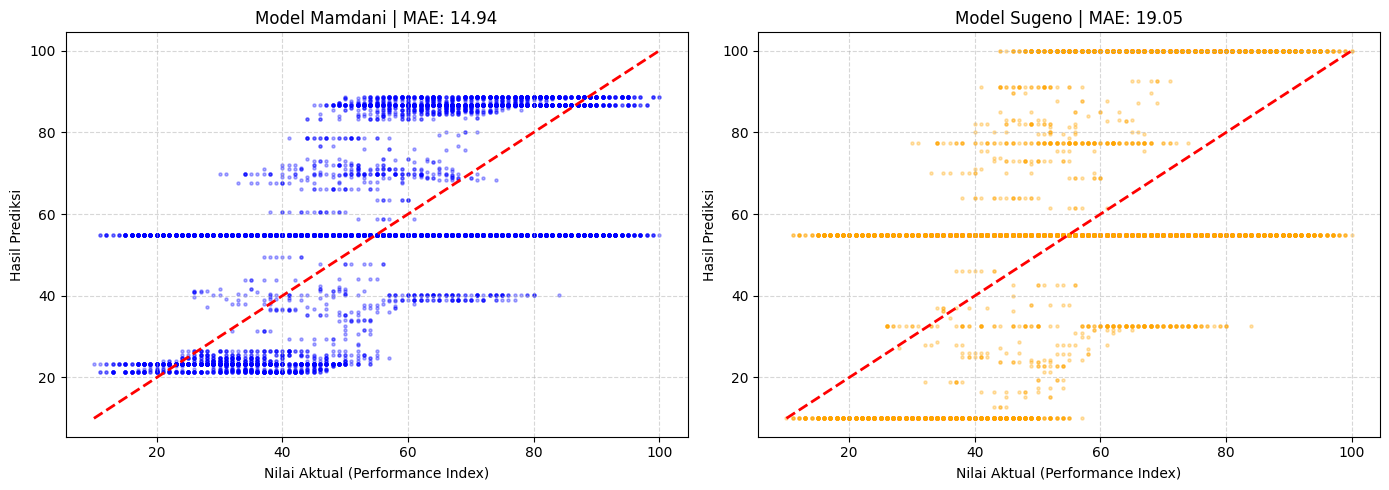

In [10]:
import matplotlib.pyplot as plt

# Visualisasi Scatter plot: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot untuk Mamdani
axes[0].scatter(df['Performance Index'], df['Prediksi_Mamdani'], alpha=0.3, s=5, color='blue')
axes[0].plot([10, 100], [10, 100], 'r--', linewidth=2)
axes[0].set_title(f'Model Mamdani | MAE: {mae_mamdani:.2f}')
axes[0].set_xlabel('Nilai Aktual (Performance Index)')
axes[0].set_ylabel('Hasil Prediksi')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot untuk Sugeno
axes[1].scatter(df['Performance Index'], df['Prediksi_Sugeno'], alpha=0.3, s=5, color='orange')
axes[1].plot([10, 100], [10, 100], 'r--', linewidth=2)
axes[1].set_title(f'Model Sugeno | MAE: {mae_sugeno:.2f}')
axes[1].set_xlabel('Nilai Aktual (Performance Index)')
axes[1].set_ylabel('Hasil Prediksi')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# Kesimpulan Akhir

Berdasarkan hasil evaluasi performa model menggunakan metrik MAE dan MSE pada 10.000 data:

1. **Mamdani vs Sugeno**:
   Model **Mamdani** menunjukkan tingkat kesalahan yang lebih rendah dibandingkan model **Sugeno**. Hal ini disebabkan karena metode Defuzzifikasi Mamdani (Centroid) melakukan kalkulasi luasan area gabungan yang bersifat kontinu dan dinamis. Ini menghasilkan transisi nilai output yang jauh lebih halus dan presisi, berbeda dengan model Sugeno Orde-0 yang membatasi output pada konstanta singleton yang kaku (*rigid*).

### Interpretasi: Kelebihan & Kekurangan Metode

**Metode Mamdani**
*   ✅ Kelebihan: Output prediksi jauh lebih halus (menggunakan centroid), representasi output lebih alami secara linguistik, dan alur logikanya lebih mudah diinterpretasi oleh penalaran manusia.
*   ❌ Kekurangan: Beban komputasi relatif lebih lambat, membutuhkan proses diskritisasi area luasan yang panjang, dan secara matematis jauh lebih kompleks.

**Metode Sugeno (Orde-0)**
*   ✅ Kelebihan: Beban komputasi sangat cepat dan ringan (karena hanya menggunakan rumus weighted average), sehingga sangat cocok dan stabil untuk sistem kontrol real-time.
*   ❌ Kekurangan: Output terbatas pada konstanta singleton yang kaku, sehingga kurang fleksibel untuk merepresentasikan rentang variasi output yang dinamis dan kompleks.

2. **Analisis Error**:
   Nilai error yang dihasilkan dari kedua model masih tergolong wajar. Batasan utama sistem ini adalah penggunaan **15 Rule Base** saja. Jumlah aturan tersebut belum mencakup seluruh ruang probabilitas kombinasi varians dari kelima fitur input terhadap variasi riil yang ada pada 10.000 data. Namun demikian, rancangan logika fuzzy *from scratch* ini berhasil berjalan dengan sangat cepat dan efisien tanpa melakukan perulangan lambat berkat teknik vektorisasi NumPy dan Pandas.
